### Annual and monthly climatologies of key variables 
### Results: Section 1a

In [10]:
import sys
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import geopandas as gpd
from shapely.geometry import mapping
from scipy.stats import spearmanr, pearsonr
import pandas as pd
import gc
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import grangercausalitytests

import warnings
warnings.filterwarnings('ignore')

In [11]:
datap = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/"
datac = "/Users/ellendyer/Documents/GitHub/F4R_data/"
dataf = "/Users/ellendyer/Documents/GitHub/F4R_data/analysed_fapar/"
datal = "/Users/ellendyer/Documents/GitHub/F4R_data/analysed_lai/"
datam = "/Users/ellendyer/Documents/GitHub/F4R_data/analysed_modis/"
datat = "/Users/ellendyer/Documents/GitHub/F4R_data/analysed_tropomi/"
datatr = "/Users/ellendyer/Documents/GitHub/F4R_data/tropess_regrid/"

In [12]:
fapar = xr.open_mfdataset(dataf+'fapar_*_10day_reg_regrid.nc')
evap = xr.open_mfdataset(datam+'modis_*_10day_reg_regrid.nc')*0.1/8.0
precip = xr.open_mfdataset(datac+'chirps_10day_reg_regrid.nc') 
t2m = xr.open_mfdataset(datac+'era5_10day_reg_regrid.nc')-273.0 
lai = xr.open_mfdataset(datal+'lai_*_reg_regrid.nc') 
sif = xr.open_mfdataset(datac+'sif_10day_reg_regrid.nc') 
hdo = xr.open_mfdataset(datac+'hdo_10day_reg_regrid.nc') 
tropess = xr.open_dataset(datatr+'tropess_gridded_caf_multl_2018_2024.nc') 
tropess = tropess.sel(level=slice(700,500)).mean('level')

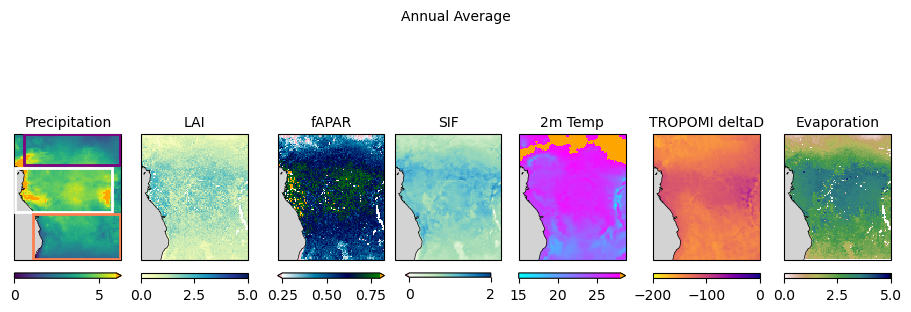

<Figure size 640x480 with 0 Axes>

In [13]:
ncols=7
nrows=1
h = nrows
w = ncols

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(9,3))
axs=axs.flatten()

cmap=plt.cm.viridis
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')
cst=precip['precip'].mean('time').plot.pcolormesh(ax=axs[0],
                    vmin=0, vmax=6,
                    cmap=cmap,
                    rasterized=True,
                    cbar_kwargs={"label": "","orientation":"horizontal"},
                    transform = ccrs.PlateCarree())
axs[0].add_patch(plt.Rectangle((10, 5.2), 20.7, 6.7, ls="-", lw=2, ec="purple", fc="none",zorder=3))
axs[0].add_patch(plt.Rectangle((8, -4.9), 21, 9.6, ls="-", lw=2, ec="white", fc="none",zorder=3))
axs[0].add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=2, ec="coral", fc="none",zorder=3))
axs[0].set_title('Precipitation',fontsize=10)
axs[0].set_ylabel('EQ')
axs[0].coastlines()
axs[0].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

cmap=plt.cm.YlGnBu
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')
cst=lai['LAI'].mean('time').plot.pcolormesh(ax=axs[1],
                    vmin=0, vmax=5,
                    cmap=cmap,
                    rasterized=True,
                    cbar_kwargs={"label": "","orientation":"horizontal"},
                    transform = ccrs.PlateCarree())
axs[1].set_title('LAI',fontsize=10)
axs[1].coastlines()
axs[1].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

cmap=plt.cm.ocean_r
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')
cst=fapar['fAPAR'].mean('time').plot.pcolormesh(ax=axs[2],
                    vmin=0.25, vmax=0.8,
                    cmap=cmap,
                    rasterized=True,
                    cbar_kwargs={"label": "","orientation":"horizontal"},
                    transform = ccrs.PlateCarree())
axs[2].set_title('fAPAR',fontsize=10)
axs[2].coastlines()
axs[2].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

cmap=plt.cm.GnBu
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')
cst=sif['SIF'].mean('time').plot.pcolormesh(ax=axs[3],
                    cmap=cmap,
                    vmin=0, vmax=2,
                    rasterized=True,
                    cbar_kwargs={"label": "","orientation":"horizontal","shrink":0.8},
                    transform = ccrs.PlateCarree())
axs[3].set_title('SIF',fontsize=10)
axs[3].coastlines()
axs[3].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

cmap=plt.cm.cool
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')
cst=t2m['t2m'].mean('time').plot.pcolormesh(ax=axs[4],
                    vmin=15, vmax=28.0,
                    cmap=cmap,
                    rasterized=True,
                    cbar_kwargs={"label": "","orientation":"horizontal"},
                    transform = ccrs.PlateCarree())
axs[4].set_title('2m Temp',fontsize=10)
axs[4].coastlines()
axs[4].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

#cmap=plt.cm.plasma_r
#cmap.set_extremes(over='green')
#cmap.set_extremes(under='grey')
#cst=tropess['deltaD'].mean('time').plot.pcolormesh(ax=axs[4],
#                    vmin=-150, vmax=-50.0,
#                    cmap=cmap,
#                    rasterized=True,
#                    cbar_kwargs={"label": "","orientation":"horizontal"},
#                    transform = ccrs.PlateCarree())
#axs[4].set_title('TROPESS deltaD',fontsize=10)
#axs[4].coastlines()
#axs[4].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

cmap=plt.cm.plasma_r
cmap.set_extremes(over='green')
cmap.set_extremes(under='lightblue')
cst=hdo['deltaD'].mean('time').plot.pcolormesh(ax=axs[5],
                    vmin=-200, vmax=0.0,
                    cmap=cmap,
                    rasterized=True,
                    cbar_kwargs={"label": "","orientation":"horizontal"},
                    transform = ccrs.PlateCarree())
axs[5].set_title('TROPOMI deltaD',fontsize=10)
axs[5].coastlines()
axs[5].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

#cmap=plt.cm.summer_r
cmap=plt.cm.gist_earth_r
cmap.set_extremes(over='green')
cmap.set_extremes(under='lightblue')
cst=evap['ET_500m'].mean('time').plot.pcolormesh(ax=axs[6],
                    vmin=0, vmax=5.0,
                    cmap=cmap,
                    rasterized=True,
                    cbar_kwargs={"label": "","orientation":"horizontal"},
                    transform = ccrs.PlateCarree())
axs[6].set_title('Evaporation',fontsize=10)
axs[6].coastlines()
axs[6].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

#cmap=plt.cm.tab20b
#cmap.set_extremes(over='orange')
#cmap.set_extremes(under='pink')
#cst=vclass_plot.plot.pcolormesh(ax=axs[5],
#                    cmap=cmap,
#                    levels=[45,55,65,75,85,95,105,125,135],
#                    rasterized=True,
#                    cbar_kwargs={"label": "","orientation":"horizontal","shrink":0.8,
#                                 'ticks': [50, 60, 70, 80, 90,110,120, 130]},
#                    transform = ccrs.PlateCarree())
#cst.colorbar.ax.set_xticklabels(['BroadL EG','BroadL D','Needle EG','Needle D','Mixed Tree','Mosaic','Shrub','Grassland'], rotation=45)
#axs[5].add_patch(plt.Rectangle((10, 5.2), 20.7, 6.7, ls="-", lw=2, ec="purple", fc="none",zorder=3))
#axs[5].add_patch(plt.Rectangle((8, -4.9), 21, 9.6, ls="-", lw=2, ec="white", fc="none",zorder=3))
#axs[5].add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=2, ec="coral", fc="none",zorder=3))
#axs[5].set_title('Land cover class',fontsize=10)
#axs[5].coastlines()
#axs[5].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

plt.suptitle("Annual Average", fontsize=10)
plt.savefig(datap+'annual_avg.png')
plt.show()
plt.clf()

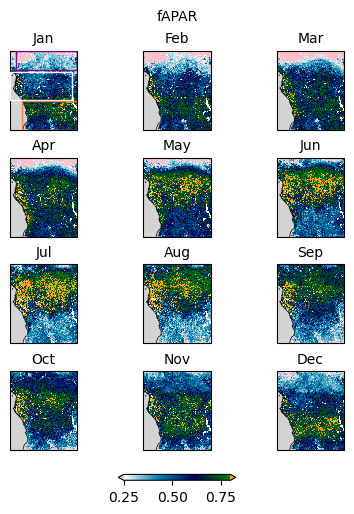

<Figure size 640x480 with 0 Axes>

In [14]:
ncols=3
nrows=4
h = nrows
w = ncols
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(4,5))
axs=axs.flatten()
var = fapar['fAPAR'].groupby('time.month').mean('time')

cmap=plt.cm.ocean_r
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')

for i in range(0,12):
    cst=var[i,:,:].plot.pcolormesh(ax=axs[i],
                        vmin=0.25, vmax=0.8,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        #cbar_kwargs={"label": ""},
                        transform = ccrs.PlateCarree())
    if i==0:
        axs[0].add_patch(plt.Rectangle((10, 5.2), 20.7, 6.7, ls="-", lw=1, ec="purple", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((8, -4.9), 21, 9.6, ls="-", lw=1, ec="white", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=1, ec="coral", fc="none",zorder=3))
    axs[i].set_title(mon[i],fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

fig.subplots_adjust(hspace=0,wspace=-0.5)
cbar = fig.colorbar(cst, ax=axs, orientation='horizontal',
                        #location="bottom",
                        shrink=0.3,extend="both",fraction=0.2)

plt.suptitle("fAPAR", fontsize=10)
plt.savefig(datap+'mon_clim_fapar.png')
plt.show()
plt.clf()

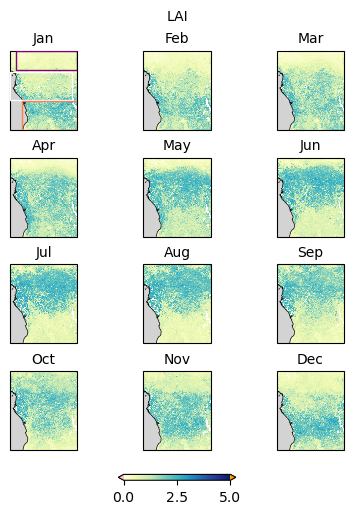

<Figure size 640x480 with 0 Axes>

In [15]:
ncols=3
nrows=4
h = nrows
w = ncols
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(4,5))
axs=axs.flatten()
var = lai['LAI'].groupby('time.month').mean('time')

cmap=plt.cm.YlGnBu
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')

for i in range(0,12):
    cst=var[i,:,:].plot.pcolormesh(ax=axs[i],
                        vmin=0.0, vmax=5.0,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        #cbar_kwargs={"label": ""},
                        transform = ccrs.PlateCarree())
    if i==0:
        axs[0].add_patch(plt.Rectangle((10, 5.2), 20.7, 6.7, ls="-", lw=1, ec="purple", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((8, -4.9), 21, 9.6, ls="-", lw=1, ec="white", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=1, ec="coral", fc="none",zorder=3))
    axs[i].set_title(mon[i],fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

fig.subplots_adjust(hspace=0,wspace=-0.5)
cbar = fig.colorbar(cst, ax=axs, orientation='horizontal',
                        #location="bottom",
                        shrink=0.3,extend="both",fraction=0.2)

plt.suptitle("LAI", fontsize=10)
plt.savefig(datap+'mon_clim_lai.png')
plt.show()
plt.clf()

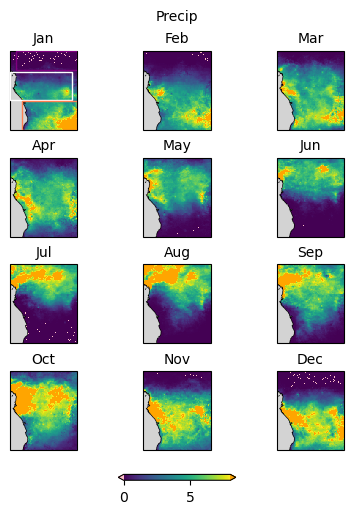

<Figure size 640x480 with 0 Axes>

In [16]:
ncols=3
nrows=4
h = nrows
w = ncols
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(4,5))
axs=axs.flatten()
var = precip['precip'].groupby('time.month').mean('time')

cmap=plt.cm.viridis
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')

for i in range(0,12):
    cst=var[i,:,:].plot.pcolormesh(ax=axs[i],
                        vmin=0.0, vmax=8.0,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        #cbar_kwargs={"label": ""},
                        transform = ccrs.PlateCarree())
    if i==0:
        axs[0].add_patch(plt.Rectangle((10, 5.2), 20.7, 6.7, ls="-", lw=1, ec="purple", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((8, -4.9), 21, 9.6, ls="-", lw=1, ec="white", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=1, ec="coral", fc="none",zorder=3))
    axs[i].set_title(mon[i],fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

fig.subplots_adjust(hspace=0,wspace=-0.5)
cbar = fig.colorbar(cst, ax=axs, orientation='horizontal',
                        #location="bottom",
                        shrink=0.3,extend="both",fraction=0.2)

plt.suptitle("Precip", fontsize=10)
plt.savefig(datap+'mon_clim_precip.png')
plt.show()
plt.clf()

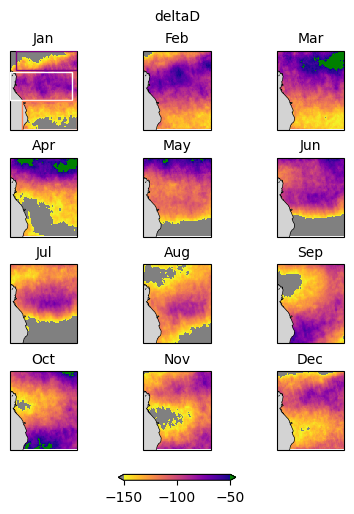

<Figure size 640x480 with 0 Axes>

In [17]:
ncols=3
nrows=4
h = nrows
w = ncols
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(4,5))
axs=axs.flatten()
var = tropess['deltaD'].groupby('time.month').mean('time')

cmap=plt.cm.plasma_r
cmap.set_extremes(over='green')
cmap.set_extremes(under='grey')

for i in range(0,12):
    cst=var[i,:,:].plot.pcolormesh(ax=axs[i],
                        vmin=-150, vmax=-50.0,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        #cbar_kwargs={"label": ""},
                        transform = ccrs.PlateCarree())
    if i==0:
        axs[0].add_patch(plt.Rectangle((10, 5.2), 20.7, 6.7, ls="-", lw=1, ec="purple", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((8, -4.9), 21, 9.6, ls="-", lw=1, ec="white", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=1, ec="coral", fc="none",zorder=3))
    axs[i].set_title(mon[i],fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

fig.subplots_adjust(hspace=0,wspace=-0.5)
cbar = fig.colorbar(cst, ax=axs, orientation='horizontal',
                        #location="bottom",
                        shrink=0.3,extend="both",fraction=0.2)

plt.suptitle("deltaD", fontsize=10)
plt.savefig(datap+'mon_clim_tropess_deltaD.png')
plt.show()
plt.clf()

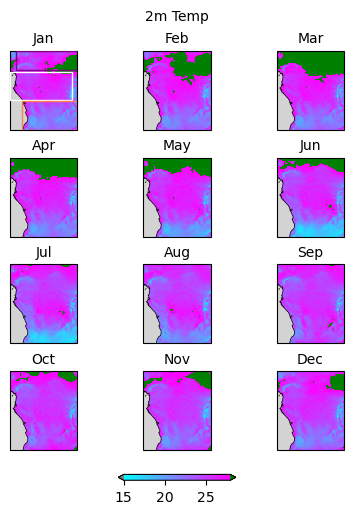

<Figure size 640x480 with 0 Axes>

In [18]:
ncols=3
nrows=4
h = nrows
w = ncols
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(4,5))
axs=axs.flatten()
var = t2m['t2m'].groupby('time.month').mean('time')

cmap=plt.cm.cool
cmap.set_extremes(over='green')
cmap.set_extremes(under='grey')

for i in range(0,12):
    cst=var[i,:,:].plot.pcolormesh(ax=axs[i],
                        vmin=15, vmax=28.0,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        #cbar_kwargs={"label": ""},
                        transform = ccrs.PlateCarree())
    if i==0:
        axs[0].add_patch(plt.Rectangle((10, 5.2), 20.7, 6.7, ls="-", lw=1, ec="purple", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((8, -4.9), 21, 9.6, ls="-", lw=1, ec="white", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=1, ec="coral", fc="none",zorder=3))
    axs[i].set_title(mon[i],fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

fig.subplots_adjust(hspace=0,wspace=-0.5)
cbar = fig.colorbar(cst, ax=axs, orientation='horizontal',
                        #location="bottom",
                        shrink=0.3,extend="both",fraction=0.2)

plt.suptitle("2m Temp", fontsize=10)
plt.savefig(datap+'mon_clim_t2m.png')
plt.show()
plt.clf()

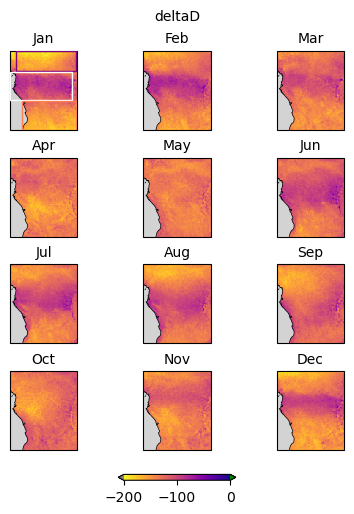

<Figure size 640x480 with 0 Axes>

In [19]:
ncols=3
nrows=4
h = nrows
w = ncols
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(4,5))
axs=axs.flatten()
var = hdo['deltaD'].groupby('time.month').mean('time')

cmap=plt.cm.plasma_r
cmap.set_extremes(over='green')
cmap.set_extremes(under='grey')
cmap.set_bad(color='white') 

for i in range(0,12):
    cst=var[i,:,:].plot.pcolormesh(ax=axs[i],
                        vmin=-200, 
                        vmax=0.0,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        #cbar_kwargs={"label": ""},
                        transform = ccrs.PlateCarree())
    if i==0:
        axs[0].add_patch(plt.Rectangle((10, 5.2), 20.7, 6.7, ls="-", lw=1, ec="purple", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((8, -4.9), 21, 9.6, ls="-", lw=1, ec="white", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=1, ec="coral", fc="none",zorder=3))
    axs[i].set_title(mon[i],fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

fig.subplots_adjust(hspace=0,wspace=-0.5)
cbar = fig.colorbar(cst, ax=axs, orientation='horizontal',
                        #location="bottom",
                        shrink=0.3,extend="both",fraction=0.2)

plt.suptitle("deltaD", fontsize=10)
plt.savefig(datap+'mon_clim_hdo_deltaD.png')
plt.show()
plt.clf()

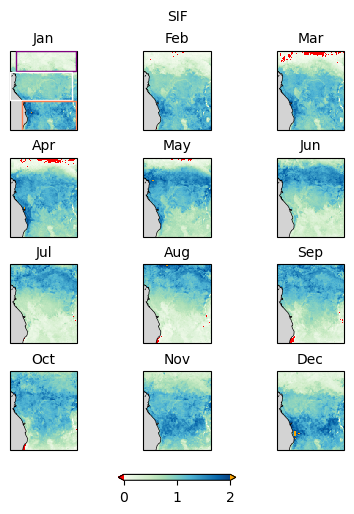

<Figure size 640x480 with 0 Axes>

In [20]:
ncols=3
nrows=4
h = nrows
w = ncols
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(4,5))
axs=axs.flatten()
var = sif['SIF'].groupby('time.month').mean('time')

cmap=plt.cm.GnBu
cmap.set_extremes(over='orange')
cmap.set_extremes(under='red')

for i in range(0,12):
    cst=var[i,:,:].plot.pcolormesh(ax=axs[i],
                        vmin=0, vmax=2,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        #cbar_kwargs={"label": ""},
                        transform = ccrs.PlateCarree())
    if i==0:
        axs[0].add_patch(plt.Rectangle((10, 5.2), 20.7, 6.7, ls="-", lw=1, ec="purple", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((8, -4.9), 21, 9.6, ls="-", lw=1, ec="white", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=1, ec="coral", fc="none",zorder=3))
    axs[i].set_title(mon[i],fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

fig.subplots_adjust(hspace=0,wspace=-0.5)
cbar = fig.colorbar(cst, ax=axs, orientation='horizontal',
                        #location="bottom",
                        shrink=0.3,extend="both",fraction=0.2)

plt.suptitle("SIF", fontsize=10)
plt.savefig(datap+'mon_clim_SIF.png')
plt.show()
plt.clf()

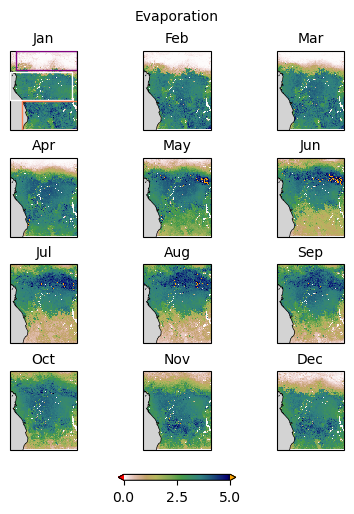

<Figure size 640x480 with 0 Axes>

In [21]:
ncols=3
nrows=4
h = nrows
w = ncols
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(4,5))
axs=axs.flatten()
var = evap['ET_500m'].groupby('time.month').mean('time')

#cmap=plt.cm.summer_r
cmap=plt.cm.gist_earth_r
cmap.set_extremes(over='orange')
cmap.set_extremes(under='red')

for i in range(0,12):
    cst=var[i,:,:].plot.pcolormesh(ax=axs[i],
                        vmin=0, vmax=5,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=False,
                        #cbar_kwargs={"label": ""},
                        transform = ccrs.PlateCarree())
    if i==0:
        axs[0].add_patch(plt.Rectangle((10, 5.2), 20.7, 6.7, ls="-", lw=1, ec="purple", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((8, -4.9), 21, 9.6, ls="-", lw=1, ec="white", fc="none",zorder=3))
        axs[0].add_patch(plt.Rectangle((12, -15), 18.7, 9.8, ls="-", lw=1, ec="coral", fc="none",zorder=3))
    axs[i].set_title(mon[i],fontsize=10)
    axs[i].coastlines()
    axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')

fig.subplots_adjust(hspace=0,wspace=-0.5)
cbar = fig.colorbar(cst, ax=axs, orientation='horizontal',
                        #location="bottom",
                        shrink=0.3,extend="both",fraction=0.2)

plt.suptitle("Evaporation", fontsize=10)
plt.savefig(datap+'mon_clim_evap.png')
plt.show()
plt.clf()